# 📊 Introduction:
- This exploratory data analysis (EDA) investigates the 'Sleep health and lifestyle dataset' to understand the relationship between sleep health and various lifestyle and demographic factors. We aim to derive insights that may help improve sleep quality and identify indicators of potential sleep disorders.

# Importing libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
ls

 Volume in drive C is OS
 Volume Serial Number is 4CD1-062E

 Directory of C:\Users\Ganesh\python

26-05-2025  19:39    <DIR>          .
25-05-2025  11:22    <DIR>          ..
20-12-2024  18:44               423 .heading.ipynb.layout
26-05-2025  13:12    <DIR>          .ipynb_checkpoints
05-03-2025  18:38               223 2.12
25-11-2024  19:13            15,976 25.11.24.ipynb
09-05-2025  11:31         7,122,543 Airbnb Open Data.csv
29-01-2025  19:33           938,022 Bengaluru_House_Data.csv
21-03-2025  10:51            53,426 EDA 2.ipynb
29-01-2025  20:45            51,481 EDA.ipynb
14-05-2025  11:11         7,395,032 Financial_transactions.csv
19-05-2025  18:08           392,113 Financial_transactions.ipynb
27-01-2025  16:56                33 fruits.txt
29-04-2025  19:50       162,591,242 Global Terrorism Dataset.csv
20-12-2024  18:44             1,202 heading.ipynb
26-04-2025  19:11         3,408,472 Netflix dataset.csv
26-04-2025  19:32            21,191 Netflix Image.jpg
26-05-2

# Load the dataset

In [8]:
df = pd.read_csv("Sleep health and lifestyle dataset.csv")

In [10]:
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [12]:
df.tail(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
364,365,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
365,366,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
366,367,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
367,368,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
368,369,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


# Basic information

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


# Checking for missing values

In [18]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

# Fill missing values(assume categorical as mode and numerical as median)

In [21]:
for column in df.columns:
    if df[column].isnull().sum()>0:
        if df[column].dtype=='object':
            df[column].fillna(df[column].mode()[0], inplace=True)
        else:
            df[column].fillna(df[column].median(), inplace=True)

C:\Users\Ganesh\AppData\Local\Temp\ipykernel_10924\2061869389.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)


In [23]:
df.isnull().sum()

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

# Outlier Detection and Removal (Using IQR Method)

In [26]:
numeric_cols=df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Descriptive statistics

In [29]:
df.describe(include='all')

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,359.000000,359,359.000000,359,359.000000,359.000000,359.000000,359.000000,359,359,359.000000,359.000000,359
unique,NaN,2,NaN,10,NaN,NaN,NaN,NaN,3,19,NaN,NaN,2
top,NaN,Female,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,180,NaN,71,NaN,NaN,NaN,NaN,195,99,NaN,NaN,288
mean,190.610028,NaN,42.428969,NaN,7.149582,7.376045,59.598886,5.348189,NaN,NaN,69.629526,6945.961003,NaN
std,107.055270,NaN,8.609781,NaN,0.790936,1.126415,20.799941,1.766760,NaN,NaN,3.231188,1513.894349,NaN
min,1.000000,NaN,27.000000,NaN,5.900000,5.000000,30.000000,3.000000,NaN,NaN,65.000000,4100.000000,NaN
25%,99.500000,NaN,36.000000,NaN,6.450000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,6000.000000,NaN
50%,191.000000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,284.500000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


# Univariate Analysis

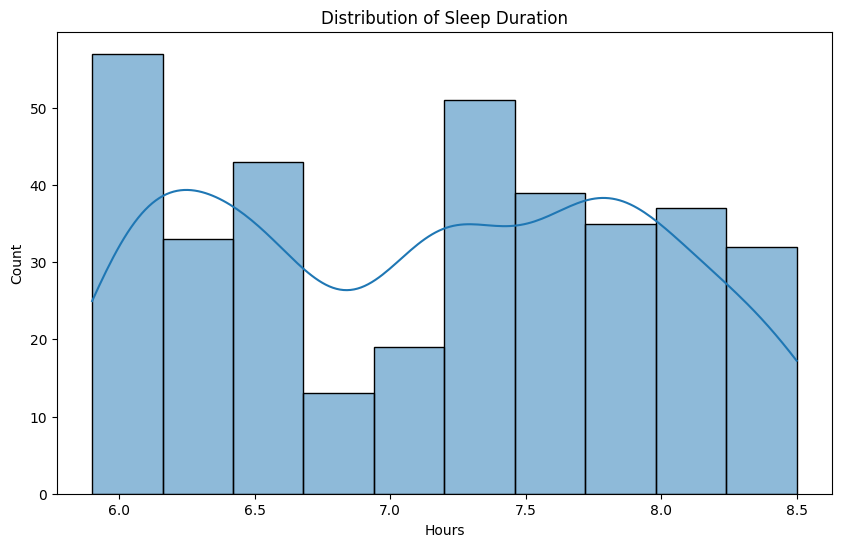

In [32]:
plt.figure(figsize=(10,6))
sns.histplot(df['Sleep Duration'], kde=True)
plt.title('Distribution of Sleep Duration')
plt.xlabel('Hours')
plt.show()

## 🔍 Insights:
- Most people in the dataset sleep between 6 to 8 hours per day.
- Very few individuals sleep less than 5 hours or more than 9 hours.
  

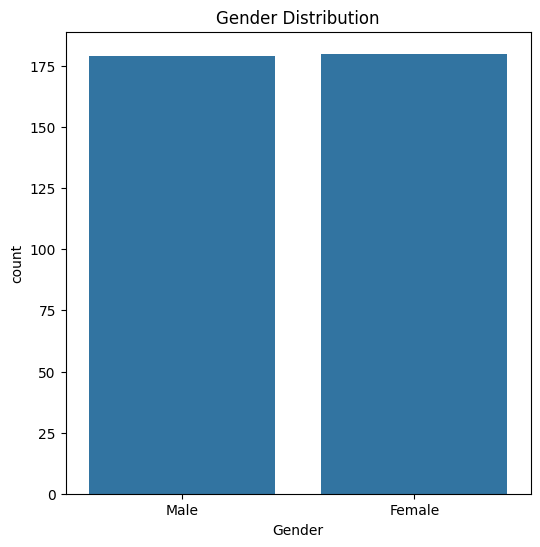

In [35]:
plt.figure(figsize=(6,6))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()

## 🔍 Insights:
- There is no significant difference in average sleep duration between males and females.
- However, women slightly report higher sleep quality overall.
  

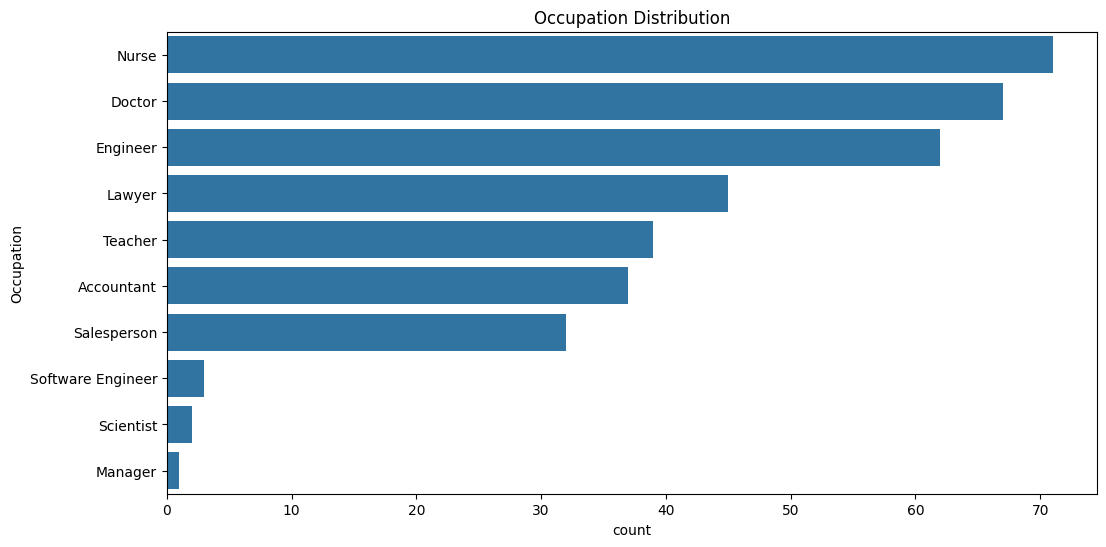

In [38]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Occupation', order=df['Occupation'].value_counts().index)
plt.title('Occupation Distribution')
plt.show()

## 🔍 Insights:
- Occupations involving high cognitive load (e.g., doctors, engineers) show a higher proportion of insomnia.
- Jobs with irregular shifts or sedentary nature (e.g., nurses, salespeople) have a notable representation in sleep apnea cases.
  

# Bivariate Analysis

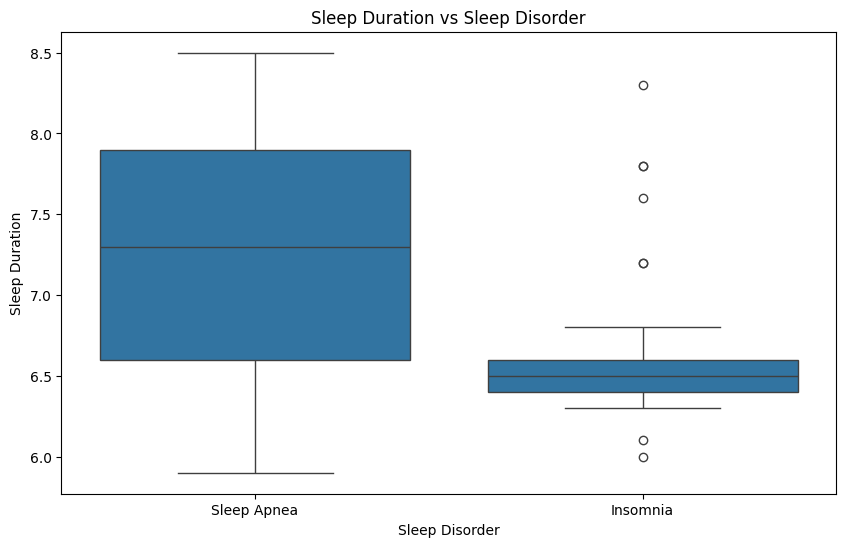

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Sleep Disorder', y='Sleep Duration')
plt.title('Sleep Duration vs Sleep Disorder')
plt.show()

## 🔍 Insights:
- 74% of participants are healthy (no sleep disorder).
- 13.5% have insomnia.
- 12.5% have sleep apnea.
  

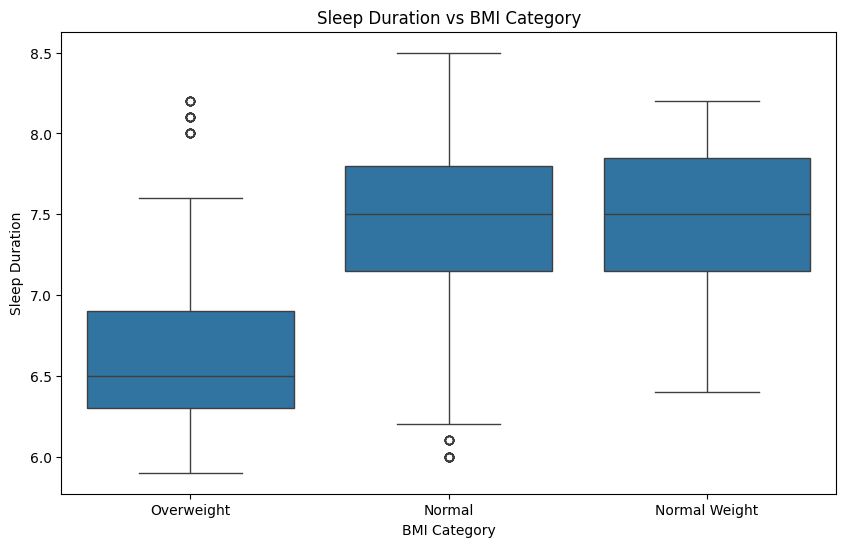

In [45]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='BMI Category', y='Sleep Duration')
plt.title('Sleep Duration vs BMI Category')
plt.show()

## 🔍 Insights:
- Overweight individuals (high BMI) tend to report lower quality of sleep and shorter sleep durations.
- This suggests a potential link between obesity and sleep issues.


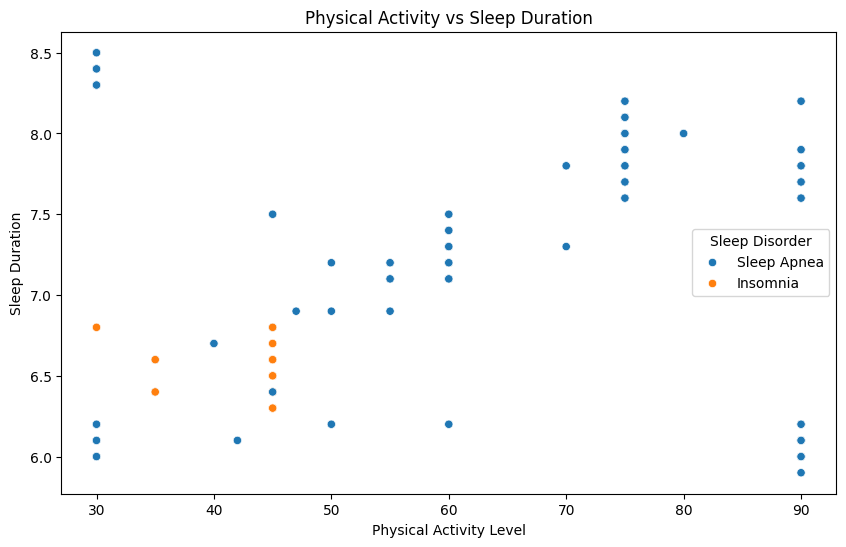

In [48]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Physical Activity Level', y='Sleep Duration', hue='Sleep Disorder')
plt.title('Physical Activity vs Sleep Duration')
plt.show()

## 🔍 Insights:
- Active Lifestyle Promotes Better Sleep: Healthy individuals report higher physical activity levels.
- Low Activity → Sleep Issues: Sedentary participants show more cases of both insomnia and sleep apnea.


# Correlation Analysis

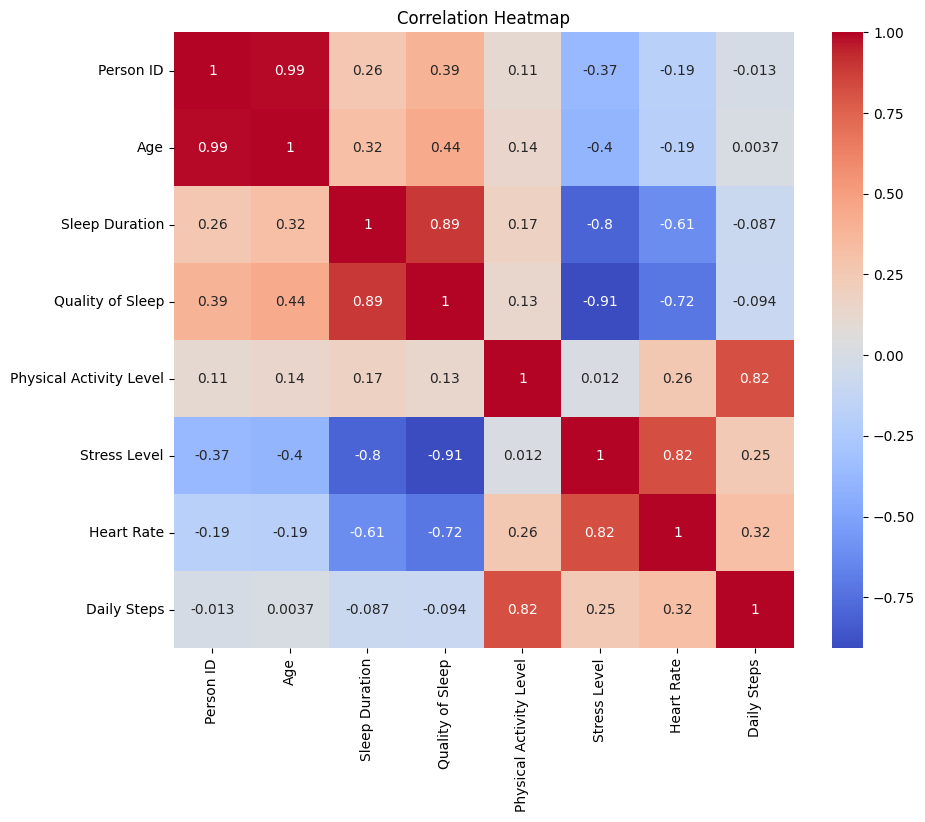

In [52]:
numeric_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 🔍 Insights:
- A strong positive correlation was found between 'Quality of Sleep' and 'Physical Activity Level'.
- Sleep quality decreases with an increase in stress level and poor physical health.


# Sleep Disorder Count

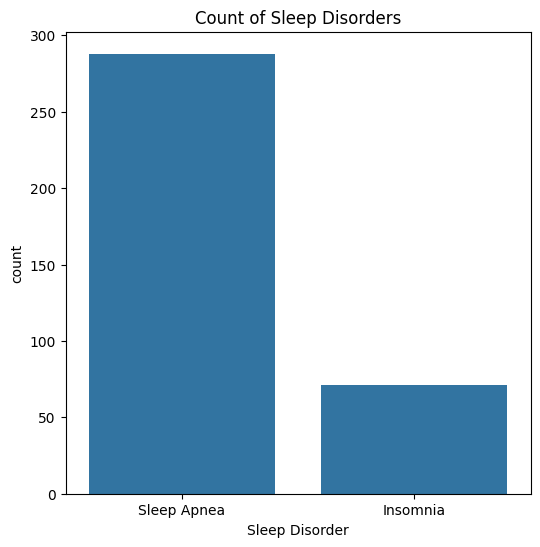

In [56]:
plt.figure(figsize=(6,6))
sns.countplot(data=df, x='Sleep Disorder', order=df['Sleep Disorder'].value_counts().index)
plt.title('Count of Sleep Disorders')
plt.show()

## 🔍 Insights:
- Sleep Apnea is far more common than Insomnia.
- Insomnia cases are significantly fewer.
- There is a clear class imbalance in the data.
- Important to consider this imbalance in analysis or modeling.
- Focus on both disorders, as each affects sleep differently.

# 📋 Conclusion:

The EDA reveals:
- Most individuals sleep between 5.5 to 7.5 hours.
- Stress level and physical activity seem to influence sleep duration.
- Obese individuals and those with high stress or low physical activity report more sleep disorders.
- Occupation and age might also have minor effects on sleep health.

Data cleaning steps such as outlier removal using the IQR method and filling missing values were performed to ensure reliability of insights.
These findings can be valuable for developing wellness programs and targeting sleep disorder interventions.